In [7]:
import seaborn as sns
# Load the "taxis" dataset
df = sns.load_dataset("taxis")
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [8]:

# Count the number of missing values
missing_values_count = df.isnull().sum()
# display the columns with missing values
missing_values = missing_values_count[missing_values_count > 0]
print(missing_values)



payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [9]:
# Impute categorical columns
df["payment"] = df["payment"].fillna(df["payment"].mode()[0])
df["pickup_zone"] = df["pickup_zone"].fillna(df["pickup_zone"].mode()[0])
df["dropoff_zone"] = df["dropoff_zone"].fillna(df["dropoff_zone"].mode()[0])
df["pickup_borough"] = df["pickup_borough"].fillna(df["pickup_borough"].mode()[0])
df["dropoff_borough"] = df["dropoff_borough"].fillna(df["dropoff_borough"].mode()[0])
print(df.isnull().sum())


pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


In [10]:
# Remove rows with missing values
df.dropna()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


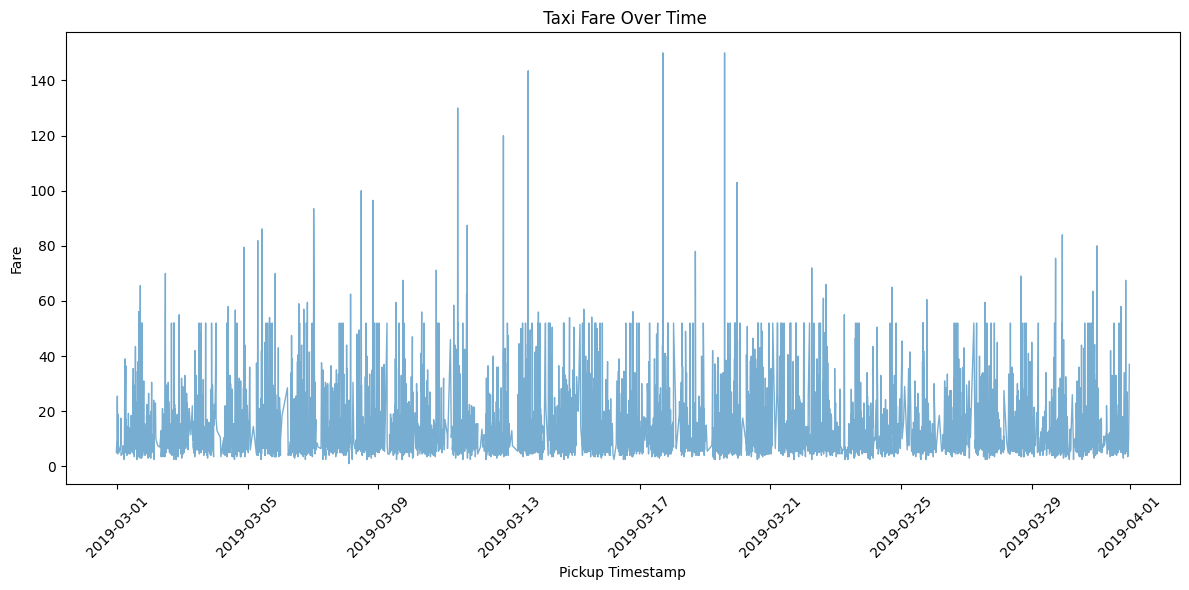

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
# Convert the pickup column to datetime
df["pickup"] = pd.to_datetime(df["pickup"])
# Sorting
df_sorted =df.sort_values("pickup")
# line chart
plt.figure(figsize=(12, 6))
plt.plot(df_sorted["pickup"], df_sorted["fare"],alpha=0.6,linewidth=1)

plt.title(" Taxi Fare Over Time")
plt.xlabel("Pickup Timestamp")
plt.ylabel("Fare")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

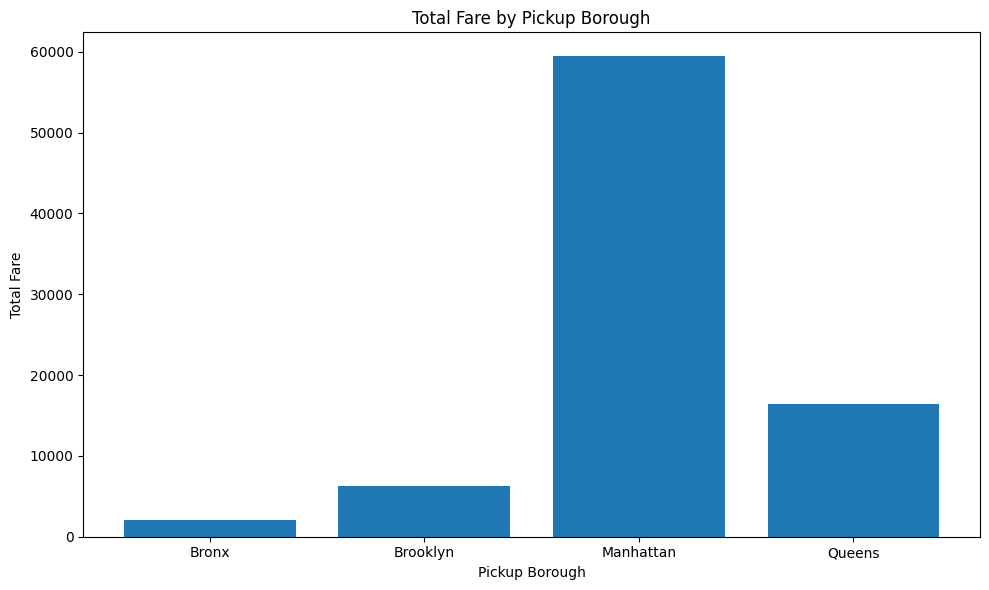

In [13]:
# Bar Chart
# Group by pickup_borought and sum the fare
borough_fare = df.groupby("pickup_borough")["fare"].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(borough_fare["pickup_borough"], borough_fare["fare"])

plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.title("Total Fare by Pickup Borough")
plt.tight_layout()
plt.show()


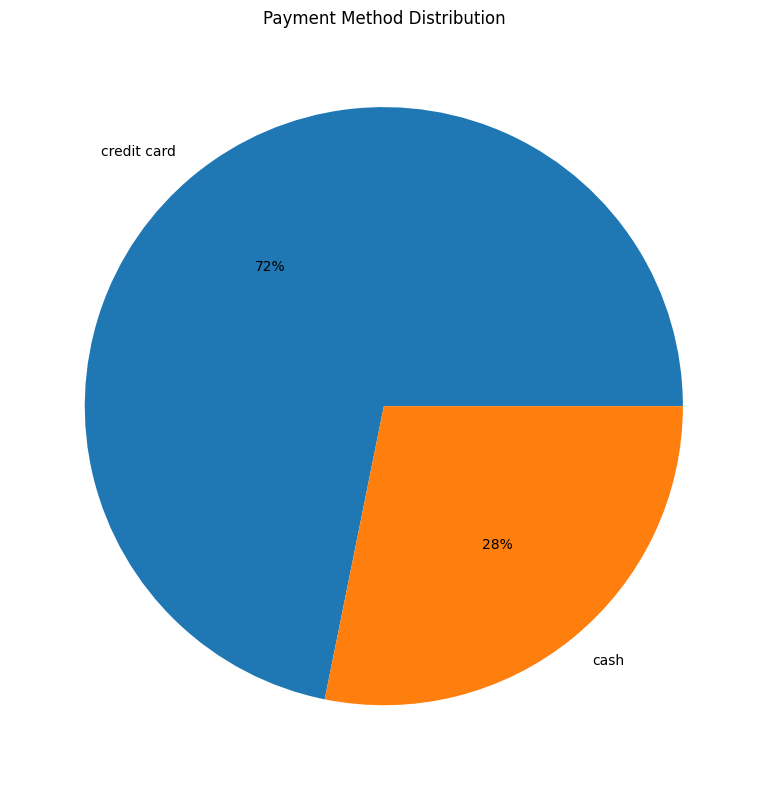

In [14]:
# Pie Chart
# Count
payment_counts = df["payment"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(payment_counts, labels=payment_counts.index,autopct="%1.0f%%")
plt.title("Payment Method Distribution")
plt.tight_layout()
plt.show()

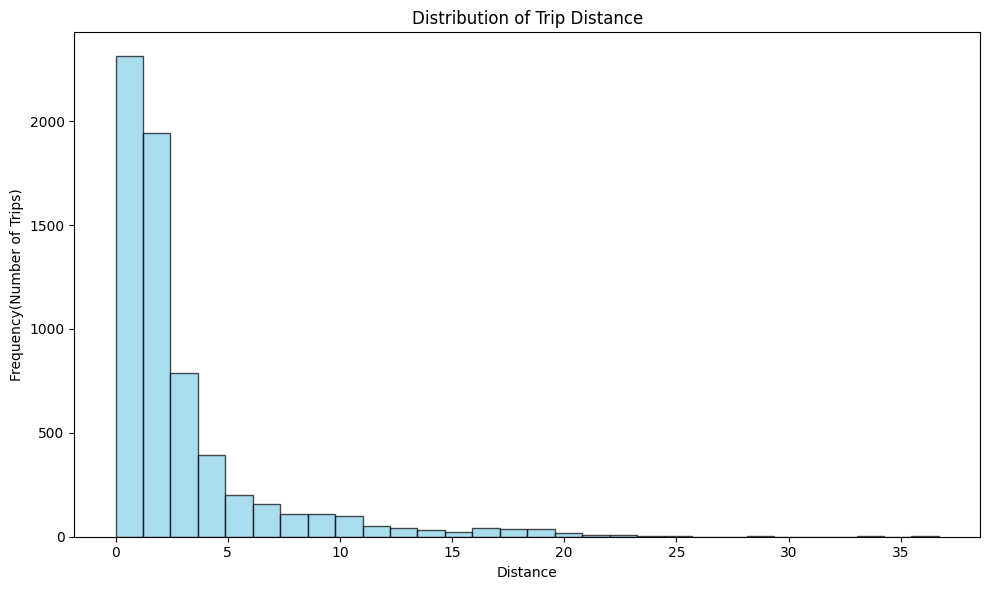

In [19]:
#  Histogram
plt.figure(figsize=(10, 6))
plt.hist(df["distance"],bins=30,color="skyblue",edgecolor="black",alpha=0.7)

plt.title("Distribution of Trip Distance")
plt.xlabel("Distance")
plt.ylabel("Frequency(Number of Trips)")
plt.tight_layout()
plt.show()

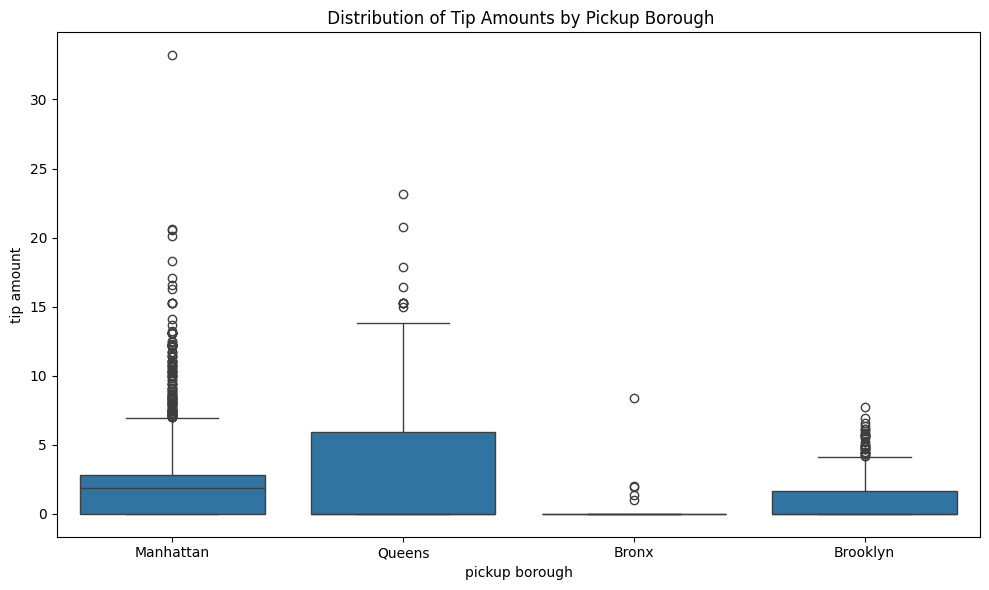

In [23]:
#   Box Plot
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x="pickup_borough", y="tip", data=df)

plt.title(" Distribution of Tip Amounts by Pickup Borough")
plt.xlabel("pickup borough")
plt.ylabel("tip amount")

plt.tight_layout()
plt.show()

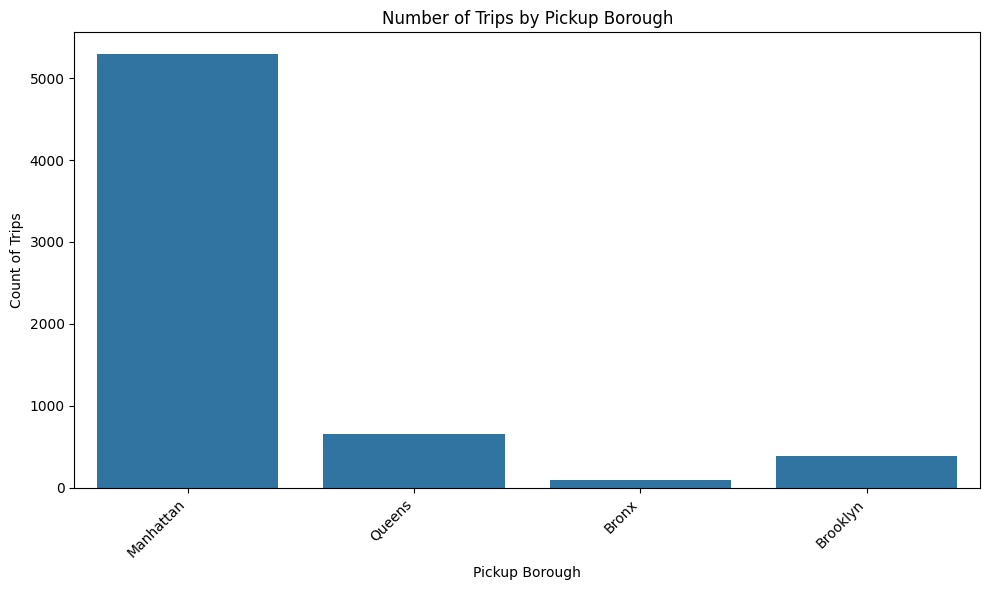

In [25]:
# Count Plot
plt.figure(figsize=(10,6))
sns.countplot(x="pickup_borough",data=df)

plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Count of Trips")
plt.xticks(rotation=45,ha="right")

plt.tight_layout()
plt.show()

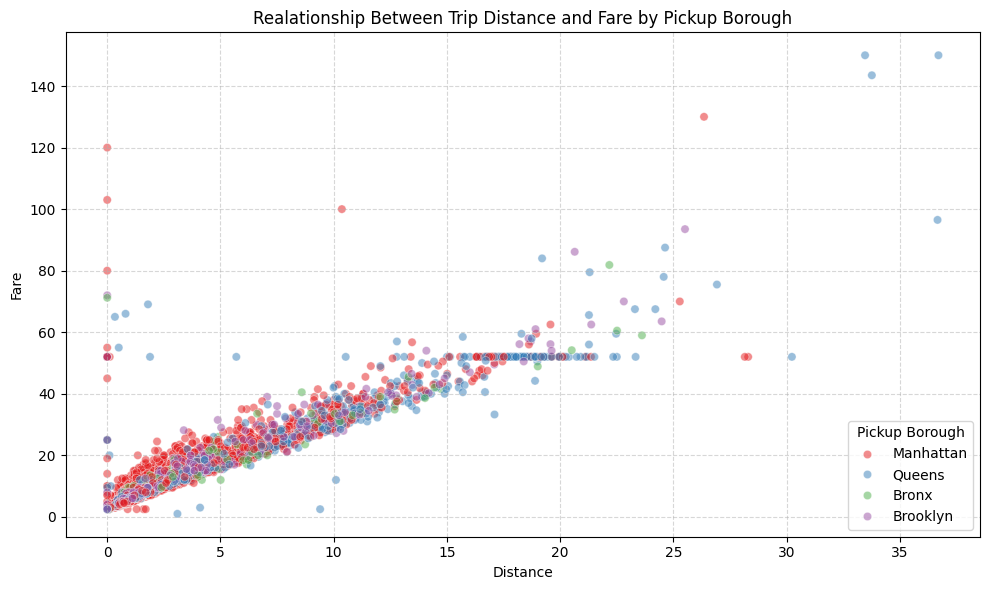

In [31]:
# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x="distance", y="fare", data=df, hue="pickup_borough", palette="Set1",alpha=0.5)

plt.title("Realationship Between Trip Distance and Fare by Pickup Borough")
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.legend(title="Pickup Borough")
plt.grid(True,linestyle="--",alpha=0.5)
plt.tight_layout()
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

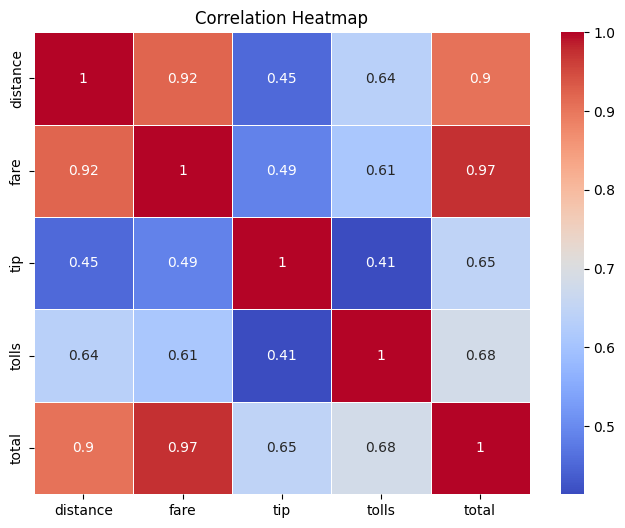

In [32]:
# Heatmap
# Numerical columns
numerical_columns = ["distance", "fare", "tip","tolls","total"]
# correlation matrix
corr_matrix = df[numerical_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5,cbar=True)

plt.title("Correlation Heatmap")
plt

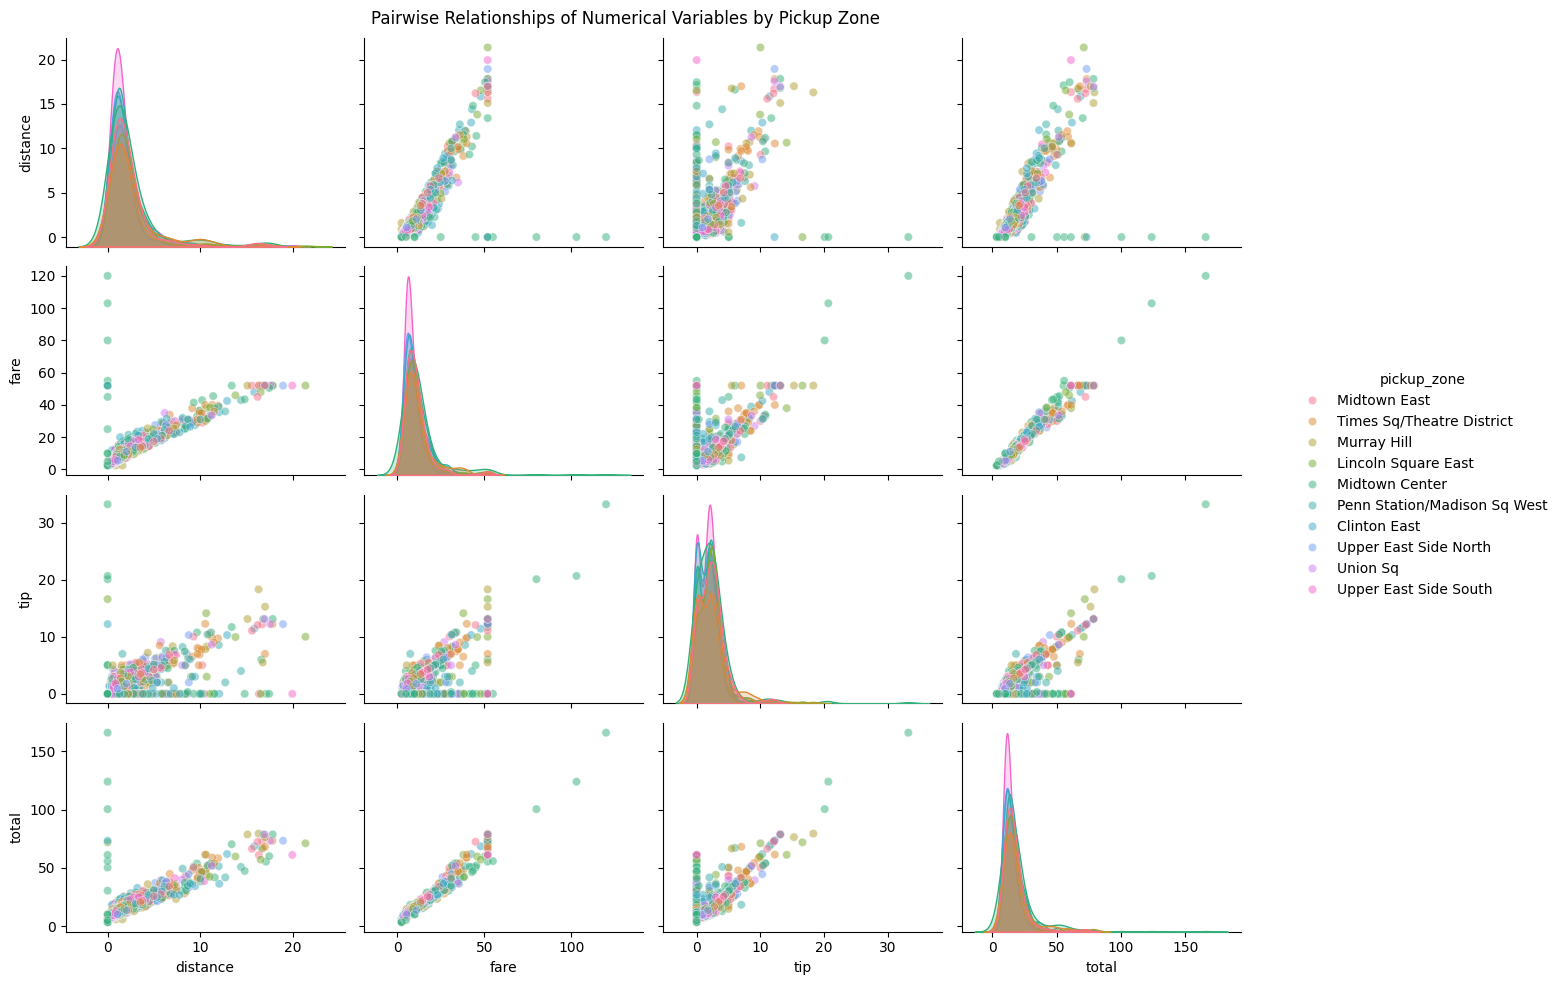

In [39]:
# Pair Plot
top_zones = df["pickup_zone"].value_counts().head(10).index
df_filtered = df[df["pickup_zone"].isin(top_zones)]

pair_columns = ["distance", "fare", "tip","total"]

p =sns.pairplot(df_filtered[pair_columns +["pickup_zone"]],
             hue="pickup_zone",
             palette="husl",
             diag_kind="kde",
             plot_kws={"alpha":0.5}
             )
p._legend.set_bbox_to_anchor((1.02,0.5))
p._legend.set_loc( "center left")
plt.subplots_adjust(top=0.9)

plt.suptitle("Pairwise Relationships of Numerical Variables by Pickup Zone")
plt.tight_layout()
plt.show()

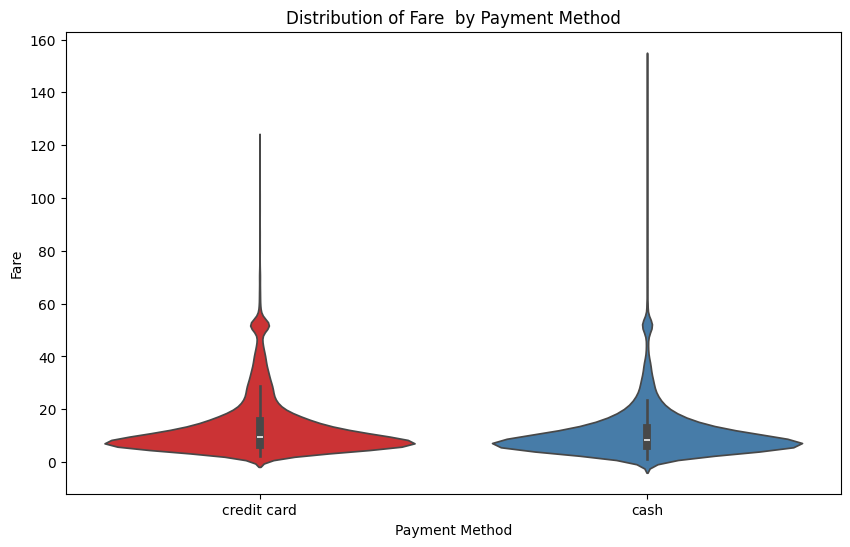

In [43]:
# Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x="payment", y="fare", data=df,hue="payment",palette="Set1",inner="box")

plt.title("Distribution of Fare  by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare")

plt.tight_layout
plt.show()